<a href="https://colab.research.google.com/github/paolatorresr90-create/Proyecto-Clasificador-de-imagenes/blob/main/Copy_of_Proyecto_Clasificaci%C3%B3n_de_Im%C3%A1genes_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

# 1. Nueva ruta simplificada
zip_path = '/content/drive/MyDrive/Colab Notebooks/Copia de dogs-vs-cats.zip'

# 2. Destino
extract_path = '/content/dataset_imagenes'

# 3. Descomprimir
try:
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    print("Descomprimiendo... esto puede tardar un minuto.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("¡LOGRADO! Archivos listos en:", extract_path)

    # Esto es para que veas qué carpetas se crearon
    print("Contenido extraído:", os.listdir(extract_path))

except Exception as e:
    print(f"Aún tenemos un problemita: {e}")

Descomprimiendo... esto puede tardar un minuto.
¡LOGRADO! Archivos listos en: /content/dataset_imagenes
Contenido extraído: ['dogs-vs-cats', '__MACOSX']


In [3]:
import os
import shutil

# 1. Definimos la ruta donde están las fotos mezcladas
train_dir = '/content/dataset_imagenes/dogs-vs-cats/train'

# 2. Definimos las rutas de las nuevas carpetas
cat_dir = os.path.join(train_dir, 'cat')
dog_dir = os.path.join(train_dir, 'dog')

# 3. Creamos las carpetas si no existen
os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

# 4. Movemos los archivos según su nombre
files = os.listdir(train_dir)
count_cats = 0
count_dogs = 0

for filename in files:
    src_path = os.path.join(train_dir, filename)

    # Solo actuamos si es un archivo (ignoramos carpetas)
    if os.path.isfile(src_path):
        if filename.startswith('cat'):
            shutil.move(src_path, os.path.join(cat_dir, filename))
            count_cats += 1
        elif filename.startswith('dog'):
            shutil.move(src_path, os.path.join(dog_dir, filename))
            count_dogs += 1

print(f"¡Proceso terminado!")
print(f"Gatos movidos: {count_cats}")
print(f"Perros movidos: {count_dogs}")

¡Proceso terminado!
Gatos movidos: 12500
Perros movidos: 12500


In [4]:
import tensorflow as tf
import numpy as np
import random
import os

def set_seed(seed=42):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Para asegurar que las operaciones en GPU sean deterministas
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seed(42)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuramos el generador (solo reescalado por ahora para ir rápido)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2) # 20% para probar

# 2. Cargamos las imágenes desde las carpetas que acabas de crear
train_generator = train_datagen.flow_from_directory(
    '/content/dataset_imagenes/dogs-vs-cats/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '/content/dataset_imagenes/dogs-vs-cats/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Base del modelo pre-entrenado
base_model = MobileNetV2(input_shape=(150, 150, 3),
                         include_top=False,
                         weights='imagenet')

# 2. CONGELAR la base para no perder lo que ya sabe
base_model.trainable = False

# 3. Crear nuestra nueva arquitectura encima
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Convierte el mapa de características en un vector
    layers.Dropout(0.2),             # Ayuda contra el overfitting
    layers.Dense(1, activation='sigmoid') # Nuestra neurona de salida (0 o 1)
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/tmp/ipykernel_520/2961198733.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Configuramos el Early Stopping (El árbitro)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,               # Si en 2 épocas no mejora, paramos
    restore_best_weights=True,
    verbose=1
)

# 2. El Checkpoint para guardar en Drive
ruta_save = '/content/drive/MyDrive/Colab Notebooks/modelo_prueba_cpu.keras'
checkpoint = ModelCheckpoint(
    ruta_save,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 3. Lanzamos el entrenamiento limitado
print("Iniciando entrenamiento de prueba en CPU...")
history = model.fit(
    train_generator,
    steps_per_epoch=50,       # Solo 50 batches de 32 fotos (1,600 fotos)
    epochs=5,                 # Intentemos 5 vueltas
    validation_data=validation_generator,
    validation_steps=10,      # Evaluamos con 320 fotos
    callbacks=[checkpoint, early_stop]
)

Iniciando entrenamiento de prueba en CPU...
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.6190 - loss: 0.7652
Epoch 1: val_accuracy improved from None to 0.93125, saving model to /content/drive/MyDrive/Colab Notebooks/modelo_prueba_cpu.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/modelo_prueba_cpu.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 874ms/step - accuracy: 0.7887 - loss: 0.4440 - val_accuracy: 0.9312 - val_loss: 0.1771
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.9472 - loss: 0.1688
Epoch 2: val_accuracy improved from 0.93125 to 0.94375, saving model to /content/drive/MyDrive/Colab Notebooks/modelo_prueba_cpu.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/modelo_prueba_cpu.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 828ms/step - accuracy: 0.9337 - loss: 0.1734 - val_accuracy: 0.9438 - val_loss: 0.1153
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9382 - loss: 0.1670
Ep

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Usamos un nombre nuevo para este modelo superior
ruta_save = '/content/drive/MyDrive/Colab Notebooks/mejor_modelo_transfer.keras'

checkpoint = ModelCheckpoint(ruta_save, monitor='val_accuracy', save_best_only=True, verbose=1)



Modelo cargado con éxito. ¡Listo para predecir!
Analizando la imagen en: /content/drive/MyDrive/Colab Notebooks/prueba2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


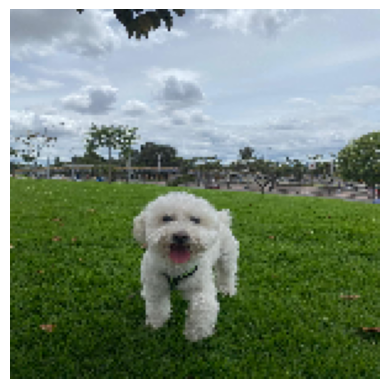

Resultado: Es un PERRO (Probabilidad: 0.9974)


In [17]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Cargar el modelo que acabas de entrenar
# Asegúrate de que la ruta coincida con la que usamos en el entrenamiento
model_path = '/content/drive/MyDrive/Colab Notebooks/modelo_prueba_cpu.keras'
model_final = tf.keras.models.load_model(model_path)

print("Modelo cargado con éxito. ¡Listo para predecir!")

# 2. Función para procesar y predecir la imagen
def predecir_animal(img_path):
    # El tamaño debe ser 150x150 como lo configuramos en el modelo
    img = image.load_img(img_path, target_size=(150, 150))
    img_tensor = image.img_to_array(img)
    img_tensor = np.expand_dims(img_tensor, axis=0)
    img_tensor /= 255.  # Normalización

    # Predicción
    prediction = model_final.predict(img_tensor)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Como usamos activación 'sigmoid', el resultado es una probabilidad
    if prediction[0] > 0.5:
        print(f"Resultado: Es un PERRO (Probabilidad: {prediction[0][0]:.4f})")
    else:
        print(f"Resultado: Es un GATO (Probabilidad: {1 - prediction[0][0]:.4f})")

# 3. Define la ruta de la imagen en Drive
imagen_prueba_path = '/content/drive/MyDrive/Colab Notebooks/prueba2.jpg'

# 4. Ejecutar la predicción
print(f'Analizando la imagen en: {imagen_prueba_path}')
predecir_animal(imagen_prueba_path)